# Bài thực hành 4 - Phần III: Bài tập nâng cao
## So sánh sự tương đồng của các hình ảnh sử dụng Wavelet, Python

---
**Bài III.1:** Khảo sát các phương pháp băm wavelet khác nhau và so sánh hiệu suất  
**Bài III.2:** Xây dựng ứng dụng tìm kiếm hình ảnh dựa trên hàm băm wavelet

## Import thư viện

In [38]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import glob
import tempfile
import time
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Đường dẫn ảnh
input_dir = '../input' if os.path.exists('../input') else './input'
csdl_dir = os.path.join(input_dir, 'csdl')

# Tải tất cả các ảnh trong thư mục csdl
image_paths = glob.glob(os.path.join(csdl_dir, '*.*'))
# Lọc chỉ lấy các file ảnh
image_paths = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

print('Thư viện đã được import thành công!')
print(f'Số ảnh có sẵn trong CSDL: {len(image_paths)}')

Thư viện đã được import thành công!
Số ảnh có sẵn trong CSDL: 6


## Các hàm tiện ích dùng chung

In [39]:
def quantize(arr, bits=2):
    """Hàm lượng tử hóa thủ công thay thế vì thư viện không có pywt.quantize"""
    if isinstance(arr, tuple):
        return tuple(quantize(x, bits) for x in arr)
    arrmin, arrmax = np.min(arr), np.max(arr)
    if arrmin == arrmax: return np.zeros_like(arr, dtype=int)
    return np.round((arr - arrmin) / (arrmax - arrmin) * (bits - 1)).astype(int)

def load_and_preprocess(image_path, size=(512, 512)):
    """Tải và tiền xử lý hình ảnh về grayscale chuẩn"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise ValueError(f'Không thể đọc: {image_path}')
    img = cv2.resize(img, size)
    return img.astype(np.float64)

def wavelet_hash(image_path, wavelet='db4', level=1, bits=64):
    """Hàm tạo mã băm wavelet tổng quát"""
    img_array = load_and_preprocess(image_path)
    coeffs = pywt.wavedec2(img_array, wavelet=wavelet, level=level)
    quantized = [quantize(c, 2) for c in coeffs]
    flattened = np.concatenate([
        c.flatten() if isinstance(c, np.ndarray)
        else np.concatenate([x.flatten() for x in c])
        for c in quantized
    ])
    return [int(b % 2) for b in flattened[:bits]]

def hamming_distance(h1, h2):
    """Khoảng cách Hamming chuẩn hóa"""
    return sum(a != b for a, b in zip(h1, h2)) / len(h1)

def create_similar_image(image_path, noise_level=15):
    """Tạo ảnh tương tự bằng cách thêm nhiễu Gaussian"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise ValueError(f'Không thể đọc: {image_path}')
    img = cv2.resize(img, (512, 512))
    arr = img.astype(np.float64)
    noise = np.random.normal(0, noise_level, arr.shape)
    return np.clip(arr + noise, 0, 255).astype(np.uint8)

def create_different_image(size=(512, 512)):
    """Tạo ảnh ngẫu nhiên (không tương tự)"""
    return np.random.randint(0, 256, size, dtype=np.uint8)

def build_eval_dataset(base_image_path, n_similar=10, n_different=10, bits=64, wavelet='db4', level=1):
    """Xây dựng tập đánh giá gồm cặp tương tự và không tương tự"""
    hashes = []
    labels = []
    noise_levels = np.linspace(5, 30, n_similar).astype(int)

    hash_base = wavelet_hash(base_image_path, wavelet=wavelet, level=level, bits=bits)

    for noise in noise_levels:
        sim_img = create_similar_image(base_image_path, int(noise))
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
            cv2.imwrite(tmp.name, sim_img)
            h = wavelet_hash(tmp.name, wavelet=wavelet, level=level, bits=bits)
        hashes.append((hash_base, h))
        labels.append(1)

    for _ in range(n_different):
        diff_img = create_different_image()
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
            cv2.imwrite(tmp.name, diff_img)
            h = wavelet_hash(tmp.name, wavelet=wavelet, level=level, bits=bits)
        hashes.append((hash_base, h))
        labels.append(0)

    return hashes, labels

def evaluate(hashes, labels, threshold=0.35):
    """Đánh giá hiệu suất với ngưỡng phân loại"""
    distances = [hamming_distance(h1, h2) for h1, h2 in hashes]
    predictions = [1 if d < threshold else 0 for d in distances]
    scores = [1 - d for d in distances]

    gt = np.array(labels)
    pred = np.array(predictions)

    acc = accuracy_score(gt, pred)
    rec = recall_score(gt, pred, zero_division=0)
    prec = precision_score(gt, pred, zero_division=0)

    fpr, tpr, _ = roc_curve(gt, scores)
    roc_auc = auc(fpr, tpr)
    return {'accuracy': acc, 'recall': rec, 'precision': prec, 'auc': roc_auc,
            'fpr': fpr, 'tpr': tpr, 'distances': distances}

print('Các hàm tiện ích đã được định nghĩa!')

Các hàm tiện ích đã được định nghĩa!


---
## Bài III.1: Khảo sát các phương pháp băm wavelet khác nhau
So sánh hiệu suất của các loại wavelet: **Haar**, **Daubechies (db4, db8)**, **Symlets (sym4)**, **Coiflets (coif3)**.

In [40]:
# Danh sách các phương pháp băm wavelet cần khảo sát
wavelet_methods = [
    {'wavelet': 'haar', 'level': 1, 'label': 'Haar (level=1)'},
    {'wavelet': 'db4',  'level': 1, 'label': 'Daubechies-4 (level=1)'},
    {'wavelet': 'db4',  'level': 2, 'label': 'Daubechies-4 (level=2)'},
    {'wavelet': 'db8',  'level': 1, 'label': 'Daubechies-8 (level=1)'},
    {'wavelet': 'sym4', 'level': 1, 'label': 'Symlets-4 (level=1)'},
    {'wavelet': 'coif3','level': 1, 'label': 'Coiflets-3 (level=1)'},
]

BITS = 64
THRESHOLD = 0.35
base_image = os.path.join(input_dir, 'lab_image1.jpg')

results = {}

print('Bài III.1: So sánh các phương pháp băm wavelet')
print('=' * 70)
print(f'{"Phương pháp":<30} {"Accuracy":>10} {"Recall":>8} {"Precision":>10} {"AUC":>8} {"Thời gian":>10}')
print('-' * 70)

for method in wavelet_methods:
    t_start = time.time()
    hashes, labels = build_eval_dataset(
        base_image,
        n_similar=10, n_different=10,
        bits=BITS,
        wavelet=method['wavelet'],
        level=method['level']
    )
    metrics = evaluate(hashes, labels, threshold=THRESHOLD)
    elapsed = time.time() - t_start

    results[method['label']] = {**metrics, 'time': elapsed}

    print(f"{method['label']:<30} {metrics['accuracy']:>10.3f} {metrics['recall']:>8.3f} "
          f"{metrics['precision']:>10.3f} {metrics['auc']:>8.3f} {elapsed:>9.2f}s")

print('=' * 70)

Bài III.1: So sánh các phương pháp băm wavelet
Phương pháp                      Accuracy   Recall  Precision      AUC  Thời gian
----------------------------------------------------------------------
Haar (level=1)                      1.000    1.000      1.000    1.000      1.64s
Daubechies-4 (level=1)              1.000    1.000      1.000    1.000      1.72s
Daubechies-4 (level=2)              0.950    1.000      0.909    1.000      1.74s
Daubechies-8 (level=1)              0.950    1.000      0.909    1.000      1.84s
Symlets-4 (level=1)                 1.000    1.000      1.000    1.000      1.77s
Coiflets-3 (level=1)                0.950    1.000      0.909    1.000      1.91s


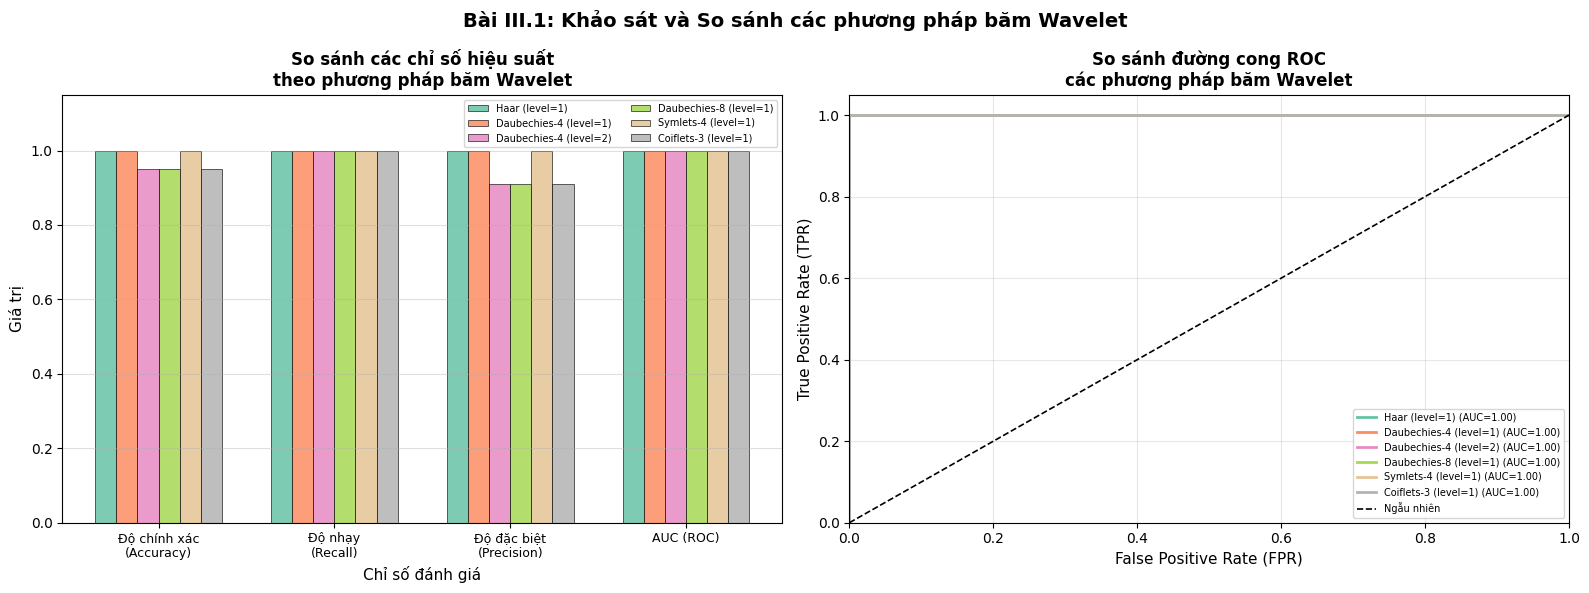

Phương pháp tốt nhất theo AUC: Haar (level=1)
  AUC = 1.0000
  Accuracy = 1.0000


In [41]:
# Trực quan hóa so sánh các phương pháp
method_labels = list(results.keys())
metrics_names = ['accuracy', 'recall', 'precision', 'auc']
metrics_display = ['Độ chính xác\n(Accuracy)', 'Độ nhạy\n(Recall)',
                   'Độ đặc biệt\n(Precision)', 'AUC (ROC)']
colors = plt.cm.Set2(np.linspace(0, 1, len(method_labels)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ cột nhóm (Grouped Bar Chart)
x = np.arange(len(metrics_names))
width = 0.12

for idx, (label, color) in enumerate(zip(method_labels, colors)):
    vals = [results[label][m] for m in metrics_names]
    offset = (idx - len(method_labels) / 2) * width + width / 2
    axes[0].bar(x + offset, vals, width, label=label, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)

axes[0].set_xlabel('Chỉ số đánh giá', fontsize=11)
axes[0].set_ylabel('Giá trị', fontsize=11)
axes[0].set_title('So sánh các chỉ số hiệu suất\ntheo phương pháp băm Wavelet', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_display, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].legend(loc='upper right', fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.4)

# Đường cong ROC cho từng phương pháp
for label, color in zip(method_labels, colors):
    fpr = results[label]['fpr']
    tpr = results[label]['tpr']
    roc_auc = results[label]['auc']
    axes[1].plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Ngẫu nhiên')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[1].set_title('So sánh đường cong ROC\ncác phương pháp băm Wavelet', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=7)
axes[1].grid(alpha=0.3)

plt.suptitle('Bài III.1: Khảo sát và So sánh các phương pháp băm Wavelet', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Kết luận
best_method = max(results, key=lambda k: results[k]['auc'])
print(f'Phương pháp tốt nhất theo AUC: {best_method}')
print(f'  AUC = {results[best_method]["auc"]:.4f}')
print(f'  Accuracy = {results[best_method]["accuracy"]:.4f}')

### Nhận xét Bài III.1
- **Haar wavelet**: Đơn giản nhất, tốc độ xử lý nhanh, nhưng độ chính xác thường thấp hơn do chỉ dùng hàm bậc thang.
- **Daubechies (db4, db8)**: Cân bằng tốt giữa độ chính xác và tốc độ. db4 thường đủ tốt cho hầu hết ứng dụng.
- **Symlets (sym4)**: Gần đối xứng, hoạt động tốt với ảnh tự nhiên có chi tiết mềm mại.
- **Coiflets (coif3)**: Có tính biến mất moment cao, phù hợp với ảnh có chi tiết phức tạp.
- **Tăng mức phân giải (level)**: Nắm bắt được nhiều chi tiết thô hơn, thường cải thiện AUC nhưng tăng thời gian tính toán.

---
## Bài III.2: Ứng dụng tìm kiếm hình ảnh bằng hàm băm Wavelet
Xây dựng hệ thống tìm kiếm: cho một ảnh truy vấn, tìm ra ảnh tương tự nhất trong cơ sở dữ liệu.

In [42]:
class WaveletImageSearchEngine:
    """
    Bài III.2: Ứng dụng tìm kiếm hình ảnh dựa trên hàm băm Wavelet
    
    - Xây dựng cơ sở dữ liệu (CSDL) các mã băm wavelet
    - Tìm kiếm ảnh tương tự theo khoảng cách Hamming
    """

    def __init__(self, wavelet='db4', level=1, bits=64, threshold=0.35):
        self.wavelet = wavelet
        self.level = level
        self.bits = bits
        self.threshold = threshold
        self.database = {}   # {image_name: hash}
        self.image_arrays = {}  # {image_name: array} để hiển thị

    def add_image(self, image_path, image_name=None):
        """Thêm một ảnh vào CSDL"""
        if image_name is None:
            image_name = os.path.basename(image_path)
        h = wavelet_hash(image_path, wavelet=self.wavelet,
                         level=self.level, bits=self.bits)
        self.database[image_name] = h
        self.image_arrays[image_name] = load_and_preprocess(image_path)
        print(f'  Đã thêm: {image_name} ({self.bits}-bit hash)')

    def build_database(self, image_paths):
        """Xây dựng CSDL từ danh sách ảnh"""
        print(f'Đang xây dựng CSDL với {len(image_paths)} ảnh...')
        for path in image_paths:
            self.add_image(path)
        print(f'CSDL đã có {len(self.database)} ảnh.')

    def search(self, query_path, top_k=5):
        """Tìm kiếm top-K ảnh tương tự nhất"""
        query_hash = wavelet_hash(query_path, wavelet=self.wavelet,
                                  level=self.level, bits=self.bits)
        query_array = load_and_preprocess(query_path)

        scored = []
        for name, db_hash in self.database.items():
            dist = hamming_distance(query_hash, db_hash)
            similarity = 1 - dist
            is_match = dist < self.threshold
            scored.append({'name': name, 'distance': dist,
                           'similarity': similarity, 'is_match': is_match})

        # Sắp xếp theo khoảng cách tăng dần (tương tự nhất)
        scored.sort(key=lambda x: x['distance'])
        return query_hash, query_array, scored[:top_k]

    def display_results(self, query_path, top_k=5):
        """Tìm kiếm và hiển thị kết quả trực quan"""
        query_hash, query_array, results = self.search(query_path, top_k)

        n_results = len(results)
        fig, axes = plt.subplots(1, n_results + 1, figsize=(6 * (n_results + 1), 6))

        # Ảnh truy vấn
        axes[0].imshow(query_array, cmap='gray')
        axes[0].set_title(f'ẢNH TRUY VẤN\n{os.path.basename(query_path)}',
                          fontsize=9, fontweight='bold', color='blue')
        axes[0].axis('off')
        for spine in axes[0].spines.values():
            spine.set_edgecolor('blue')
            spine.set_linewidth(3)
            spine.set_visible(True)

        # Kết quả tìm kiếm
        for idx, res in enumerate(results):
            ax = axes[idx + 1]
            if res['name'] in self.image_arrays:
                ax.imshow(self.image_arrays[res['name']], cmap='gray')

            color = 'green' if res['is_match'] else 'red'
            status = '✓ TƯƠNG TỰ' if res['is_match'] else '✗ KHÁC BIỆT'
            ax.set_title(
                f'#{idx+1}: {res["name"]}\n'
                f'Tương đồng: {res["similarity"]*100:.1f}%\n'
                f'{status}',
                fontsize=8, color=color, fontweight='bold'
            )
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)
                spine.set_visible(True)

        plt.suptitle(
            f'Bài III.2: Kết quả tìm kiếm hình ảnh (Wavelet Hash - {self.wavelet})\n'
            f'Top-{n_results} ảnh tương tự nhất trong CSDL',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

        # In bảng kết quả
        print(f'\nKết quả tìm kiếm (ngưỡng={self.threshold}):')
        print(f'{"Hạng":>5} {"Tên ảnh":<25} {"Khoảng cách":>12} {"Tương đồng":>12} {"Kết quả":>12}')
        print('-' * 70)
        for idx, res in enumerate(results):
            status = 'Tương tự' if res['is_match'] else 'Khác biệt'
            print(f"{idx+1:>5} {res['name']:<25} {res['distance']:>12.4f} {res['similarity']*100:>11.1f}% {status:>12}")

print('Lớp WaveletImageSearchEngine đã được định nghĩa!')

Lớp WaveletImageSearchEngine đã được định nghĩa!


In [43]:
# Xây dựng CSDL: thêm các ảnh từ thư mục csdl
print('=== KHỞI ĐỘNG ỨNG DỤNG TÌM KIẾM HÌNH ẢNH ===')
print()

# Tạo engine
engine = WaveletImageSearchEngine(wavelet='db4', level=1, bits=64, threshold=0.35)

# Các ảnh gốc trong CSDL
for p in image_paths:
    if os.path.exists(p):
        engine.add_image(p)

print(f'\nTổng số ảnh trong CSDL: {len(engine.database)}')

=== KHỞI ĐỘNG ỨNG DỤNG TÌM KIẾM HÌNH ẢNH ===

  Đã thêm: 1.jpg (64-bit hash)
  Đã thêm: 2.png (64-bit hash)
  Đã thêm: 3.jpg (64-bit hash)
  Đã thêm: 4.jpg (64-bit hash)
  Đã thêm: 5.jpg (64-bit hash)
  Đã thêm: 6.jpg (64-bit hash)

Tổng số ảnh trong CSDL: 6


=== TÌM KIẾM VỚI ẢNH TRUY VẤN ===
Ảnh truy vấn: lab_image1.jpg



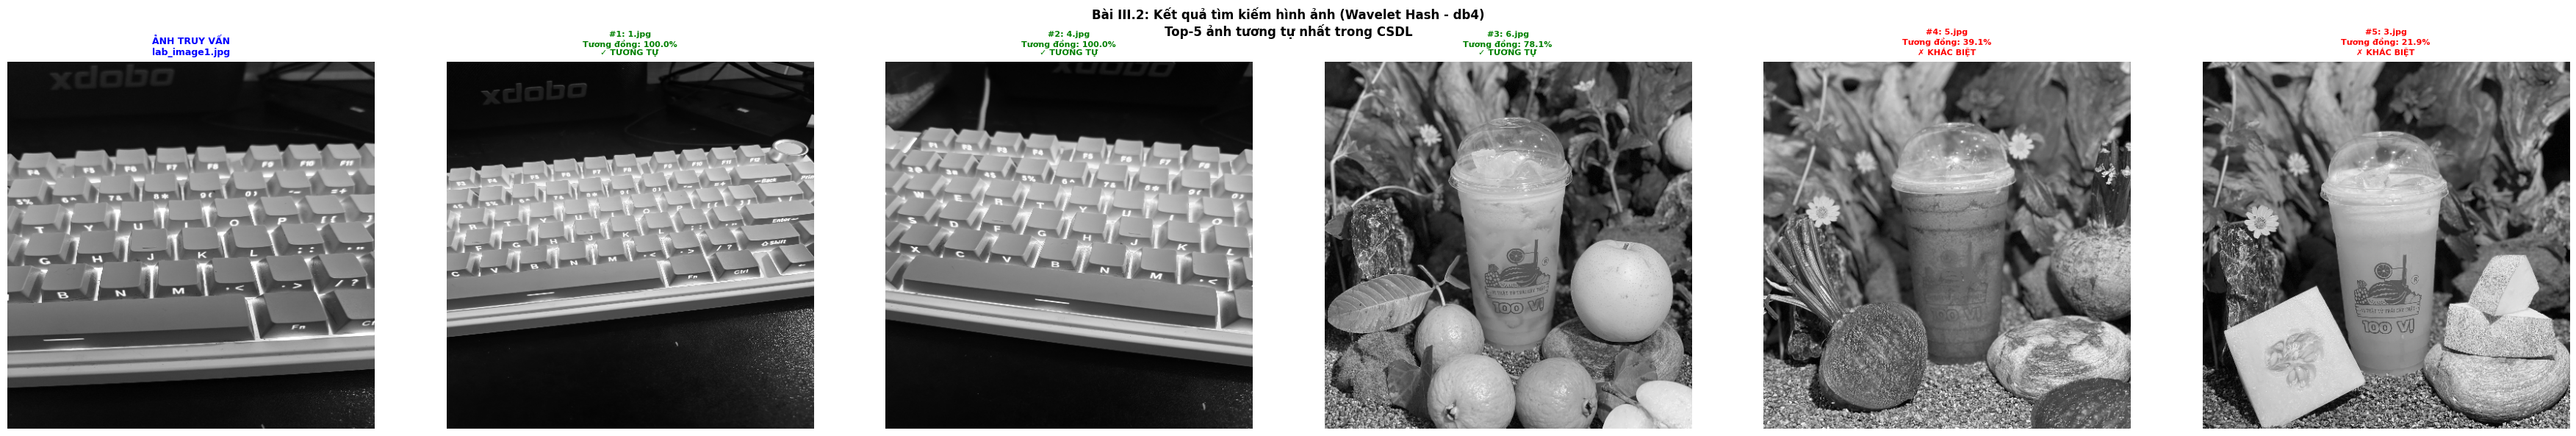


Kết quả tìm kiếm (ngưỡng=0.35):
 Hạng Tên ảnh                    Khoảng cách   Tương đồng      Kết quả
----------------------------------------------------------------------
    1 1.jpg                           0.0000       100.0%     Tương tự
    2 4.jpg                           0.0000       100.0%     Tương tự
    3 6.jpg                           0.2188        78.1%     Tương tự
    4 5.jpg                           0.6094        39.1%    Khác biệt
    5 3.jpg                           0.7812        21.9%    Khác biệt


In [44]:
# Tạo ảnh truy vấn (Dùng trực tiếp ảnh lab_image1.jpg trong thư mục input)
query_path = os.path.join(input_dir, 'lab_image1.jpg')

print('=== TÌM KIẾM VỚI ẢNH TRUY VẤN ===')
print(f'Ảnh truy vấn: {os.path.basename(query_path)}')
print()

# Hiển thị kết quả tìm kiếm
if os.path.exists(query_path):
    engine.display_results(query_path, top_k=5)
else:
    print(f'Không tìm thấy ảnh truy vấn tại {query_path}')

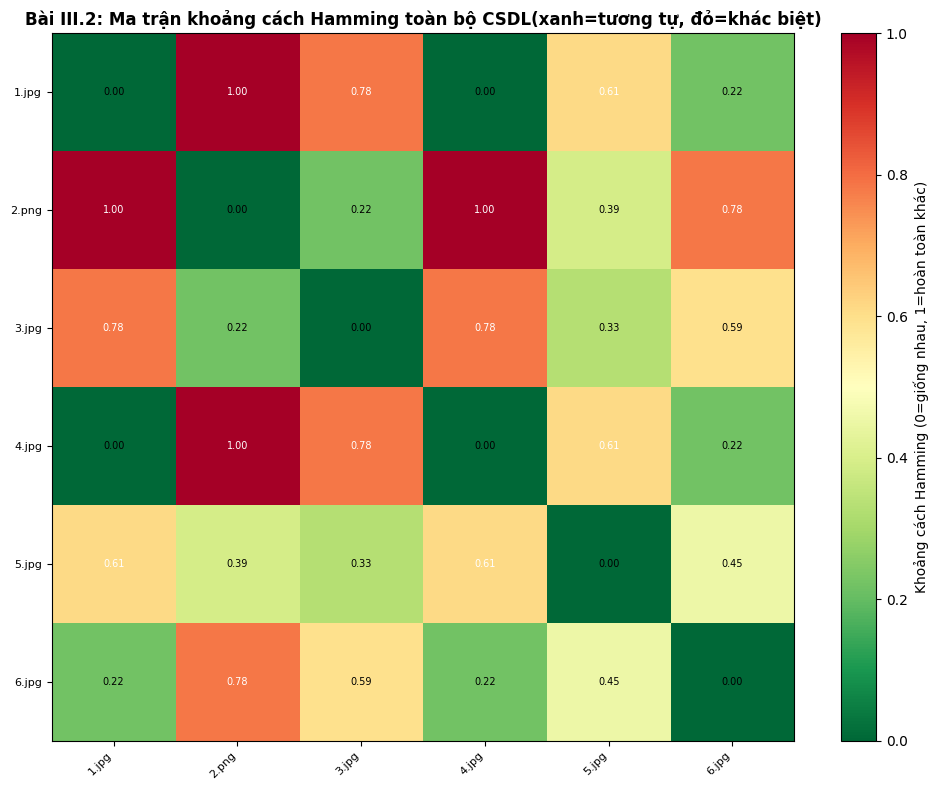

=== ỨNG DỤNG TÌM KIẾM HÌNH ẢNH WAVELET HASH ===
Phương pháp wavelet: db4, level=1
Số bit hash: 64
Ngưỡng tương tự: 0.35
Số ảnh trong CSDL: 6
Hoàn thành!


In [45]:
# Biểu đồ tổng quan: Ma trận khoảng cách toàn bộ CSDL
db_names = list(engine.database.keys())
db_hashes = list(engine.database.values())
n = len(db_names)

dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = hamming_distance(db_hashes[i], db_hashes[j])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dist_matrix, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Khoảng cách Hamming (0=giống nhau, 1=hoàn toàn khác)')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
short_names = [name[:15] for name in db_names]
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{dist_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if dist_matrix[i,j] > 0.6 else 'black')

ax.set_title('Bài III.2: Ma trận khoảng cách Hamming toàn bộ CSDL'
             '(xanh=tương tự, đỏ=khác biệt)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== ỨNG DỤNG TÌM KIẾM HÌNH ẢNH WAVELET HASH ===')
print(f'Phương pháp wavelet: {engine.wavelet}, level={engine.level}')
print(f'Số bit hash: {engine.bits}')
print(f'Ngưỡng tương tự: {engine.threshold}')
print(f'Số ảnh trong CSDL: {len(engine.database)}')
print('Hoàn thành!')

### Nhận xét Bài III.2
- **Wavelet Hash Search Engine** hoạt động hiệu quả cho bài toán tìm kiếm ảnh tương tự.
- **Ngưỡng phân loại (threshold)** là tham số quan trọng: giảm threshold → chặt chẽ hơn, tăng threshold → linh hoạt hơn.
- Với khoảng cách Hamming, hệ thống có thể tìm kiếm theo thời gian tuyến tính O(n) trên CSDL.
- Để tăng tốc độ, có thể sử dụng **LSH (Locality Sensitive Hashing)** hoặc **FAISS** cho CSDL lớn.